# YOLO VERSION 8 X

## Import Library

In [44]:
import torch 
import torch.nn as nn
from torchinfo import summary
import math 
from ultralytics import YOLO
import torch.nn.functional as F
import numpy as np 
import pkg_resources as pkg
from torch.utils.data import DataLoader, Dataset
import pandas as pd 
import matplotlib.pyplot as plt 
import itertools
import torch.optim as optim 
from PIL import Image
import torchvision.transforms as T
from pathlib import Path

## Block 

In [45]:
SCALES = {
    "n": (0.33, 0.25),
    "s": (0.33, 0.50),
    "m": (0.67, 0.75),
    "l": (1.00, 1.00),
    "x": (1.00, 1.25),
}

def autopad(k, p=None, d=1):
    if d > 1:
        k = d * (k - 1) + 1
    if p is None:
        p = k // 2
    return p

class Conv(nn.Module): 
    def __init__(self, c1, c2, k=1, s=1, p=None, g=1, d=1, act=True):
        super().__init__()
        self.conv   = nn.Conv2d(c1, c2, k, s, autopad(k, p, d), groups=g, dilation=d, bias=False) 
        self.bn     = nn.BatchNorm2d(c2, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        self.act    =  nn.SiLU(inplace=True) if act else nn.Identity()
        
    def forward (self, x):
        return self.act(self.bn(self.conv(x)))

class Bottleneck(nn.Module) : 
    def __init__(self, c1, c2 ,shortcut=True, k=3, e=0.5):
        super().__init__()
        c_ = int(e*c2)
        self.cv1 = Conv(c1, c_, k, 1)
        self.cv2 = Conv(c_, c2, k, 1)
        self.add = shortcut and c1 == c2    
        
    def forward (self, x):
        return x + self.cv2(self.cv1(x)) if self.add else self.cv2(self.cv1(x))  

class C2f(nn.Module): 
    def __init__(self, c1, c2, n=2, shortcut=False,g=1, e=0.5):
        super().__init__()
        self.c = int(c2*e)
        self.cv1 = Conv(c1, 2*self.c, 1, 1)
        self.cv2 = Conv((2+n)*self.c, c2, 1)
        self.m = nn.ModuleList(
            Bottleneck(self.c, self.c, shortcut, k=3, e = 1.0) 
            for _ in range(n)
            )
        
    def forward(self, x):
        y = list(self.cv1(x).split((self.c, self.c), 1))
        y.extend(m(y[-1]) for m in self.m)
        return self.cv2(torch.cat(y, dim=1))
        
class SPPF(nn.Module):
    def __init__(self, c1, c2, k=5, s=1):
        super().__init__()
        c_ = c1//2
        self.cv1 =Conv(c1, c_,1,1 ) 
        self.cv2 = Conv(c_*4, c2, 1,1) 
        self.m = nn.MaxPool2d(kernel_size=k, stride=s, padding=k//2)
        
    def forward(self, x):
        x = self.cv1(x)
        max1 = self.m(x)
        max2 = self.m(max1)
        return self.cv2(torch.cat((x, max1, max2, self.m(max2)),1))

class DFL(nn.Module):
    def __init__(self, reg_max=16):
        super().__init__()
        self.reg_max = reg_max
        self.conv = nn.Conv2d(reg_max, 1, 1, bias=False)
        self.conv.weight.data[:] = torch.arange(reg_max).view(1, reg_max, 1, 1)
        self.conv.weight.requires_grad = False

    def forward(self, x):
        B, C, H, W = x.shape
        x = x.view(B, 4, self.reg_max, H, W)
        x = x.softmax(2)
        x = x.view(B * 4, self.reg_max, H, W)
        x = self.conv(x)
        return x.view(B, 4, H, W)

def make_divisible(x, divisor=8):
    return math.ceil(x / divisor) * divisor

class Concat(nn.Module):
    def __init__(self, dim=1):
        super().__init__()
        self.d = dim

    def forward(self, x):
        return torch.cat(x, self.d)

## Backbone

In [46]:
class YOLOv8Backbone(nn.Module):
    def __init__(self, scale="x"):
        super().__init__()

        depth_mul, width_mul = SCALES[scale]

        base_c = [64,128,256,512,512] # Jumlah Channel
        base_n = [3, 6, 6, 3]  # Banyak Bottleneck

        c1, c2, c3, c4, c5 = [make_divisible(c * width_mul) for c in base_c] 
        # c1, c2, c3, c4, c5 = [48, 96, 192, 384, 768]
        
        n2, n3, n4, n5 = [max(round(n * depth_mul), 1) for n in base_n]
        # n2, n3, n4, n5 = [2, 4, 4, 2]

        self.out_channels = (c3, c4, c5)
        #-----------------------------------------------#
        #   3, 640, 640
        #-----------------------------------------------#
        # 3, 640, 640 => 48, 320, 320
        self.stem = Conv(3, c1, 3, 2)
        
        # 48, 320, 320 => 96, 160, 160
        self.dark2 = nn.Sequential(
            Conv(c1, c2, 3, 2),
            C2f(c2, c2, n=n2, shortcut=True)
        )

        # 96, 160, 160 => 192, 80, 80
        self.dark3 = nn.Sequential(
            Conv(c2, c3, 3, 2),
            C2f(c3, c3, n=n3, shortcut=True)
        )

        # 192, 80, 80 =>384, 40, 40  
        self.dark4 = nn.Sequential(
            Conv(c3, c4, 3, 2),
            C2f(c4, c4, n=n4, shortcut=True)
        )

        # 384, 40, 40 => 768, 20, 20
        self.dark5 = nn.Sequential(
            Conv(c4, c5, 3, 2),
            C2f(c5, c5, n=n5, shortcut=True),
            SPPF(c5, c5, 5)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.dark2(x)
        x = self.dark3(x)
        p3 = x
        x = self.dark4(x)
        p4 = x
        x = self.dark5(x)
        p5 = x
        
        # [(192, 80, 80), (384, 40, 40), (768, 20, 20)]
        return p3, p4, p5

## Neck

In [47]:
class YOLOv8Neck(nn.Module):
    def __init__(self, ch, scale="x"):
        super().__init__()

        depth_mul, _ = SCALES[scale]
        c3, c4, c5 = ch
        # [192, 384, 768] = ch
        n = max(round(3 * depth_mul), 1)

        self.upsample = nn.Upsample(scale_factor=2, mode="nearest")
        
        self.c2f_td1 = C2f(c5 + c4, c4, n=n, shortcut=False)
        self.c2f_td2 = C2f(c4 + c3, c3, n=n, shortcut=False)

        self.down1 = Conv(c3, c3, 3, 2)
        self.c2f_bu1 = C2f(c3 + c4, c4, n=n, shortcut=False)

        self.down2 = Conv(c4, c4, 3, 2)
        self.c2f_bu2 = C2f(c4 + c5, c5, n=n, shortcut=False)

    def forward(self, p3, p4, p5):
            
        # top-down
        # 768, 20, 20 => 768, 40 , 40
        p5_up = self.upsample(p5)
        
        # (768, 40, 40), (384, 40, 40)] => 1152, 40, 40 => 384, 40, 40
        p4_td = self.c2f_td1(torch.cat([p5_up, p4], dim=1))

        # 384, 40, 40 => 384, 80, 80
        p4_up = self.upsample(p4_td)
        
        # [(384, 80, 80), (192, 80, 80)] => 576, 80, 80 => 192, 80, 80
        p3_out = self.c2f_td2(torch.cat([p4_up, p3], dim=1))

        # bottom-up
        # 192, 80, 80 => 192, 40, 40 
        p3_down = self.down1(p3_out)
        
        #[(192, 40, 40),(384, 40, 40)] => 576, 40, 40 => 384, 40, 40
        p4_out = self.c2f_bu1(torch.cat([p3_down, p4_td], dim=1))

        # 384, 40, 40 => 384, 20, 20
        p4_down = self.down2(p4_out)
        
        # [(384, 20, 20), (768, 20, 20)] => 1152, 20, 20 => 768 ,20, 20
        p5_out = self.c2f_bu2(torch.cat([p4_down, p5], dim=1))
        
        #[(192, 80, 80), (384, 40, 40), (768 ,20, 20) ]
        return p3_out, p4_out, p5_out

## Head

In [48]:
class YOLOv8Head(nn.Module):
    def __init__(self, ch, nc=80, reg_max=16):
        super().__init__()

        self.nc = nc
        self.reg_max = reg_max

        self.cv2 = nn.ModuleList()  # regression
        self.cv3 = nn.ModuleList()  # classification
        self.dfl = DFL(reg_max)

        c2 = max(16, ch[0] // 4, reg_max * 4)
        c3 = max(ch[0], min(nc, 100))

        for c in ch:

            # regression branch
            self.cv2.append(
                nn.Sequential(
                    Conv(c, c2, 3),
                    Conv(c2, c2, 3),
                    nn.Conv2d(c2, 4 * reg_max, 1)
                )
            )

            # classification branch
            self.cv3.append(
                nn.Sequential(
                    Conv(c, c3, 3),
                    Conv(c3, c3, 3),
                    nn.Conv2d(c3, nc, 1)
                )
            )

    def forward(self, x):
        outputs = []

        for i in range(len(x)):
            reg = self.cv2[i](x[i])
            cls = self.cv3[i](x[i])

            outputs.append(torch.cat([reg, cls], 1))

        return outputs

## Full

In [49]:
class YOLOv8(nn.Module):
    def __init__(self, scale="x", nc=3, reg_max=16, num_temp_classes=3):
        super().__init__()

        self.num_classes = nc
        self.nc = nc
        self.reg_max = reg_max
        self.no = nc + reg_max * 4
        self.stride = torch.tensor([8., 16., 32.])

        self.backbone = YOLOv8Backbone(scale)
        ch = self.backbone.out_channels

        self.neck = YOLOv8Neck(ch, scale)
        self.head = YOLOv8Head(ch, nc, reg_max)

        # =========================
        # MLP untuk klasifikasi suhu
        # =========================
        visual_dim = ch[0] + ch[1] + ch[2]

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.temp_mlp = nn.Sequential(
            nn.Linear(visual_dim, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.SiLU(),
            nn.Dropout(0.2),

            nn.Linear(128, num_temp_classes)
        )

    def forward(self, x):
        p3, p4, p5 = self.backbone(x)
        p3, p4, p5 = self.neck(p3, p4, p5)

        # Output YOLO detection
        det_out = self.head([p3, p4, p5])

        # Output klasifikasi suhu
        v3 = self.pool(p3).flatten(1)
        v4 = self.pool(p4).flatten(1)
        v5 = self.pool(p5).flatten(1)

        visual_feat = torch.cat([v3, v4, v5], dim=1)

        temp_logits = self.temp_mlp(visual_feat)

        return det_out, temp_logits

## Data Loader

In [50]:
class YOLOTemperatureDataset(Dataset):
    def __init__(self, image_dir, label_dir, csv_path, img_size=640):
        self.image_dir = Path(image_dir)
        self.label_dir = Path(label_dir)
        self.csv_path = Path(csv_path)

        self.df = pd.read_csv(self.csv_path)

        self.label_map = {
            "Sejuk": 0,
            "Sedang": 1,
            "Dingin": 2
        }

        self.transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor()
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_name = str(row["NamaFile"]).strip()
        temp_label_text = str(row["Label"]).strip()

        if temp_label_text not in self.label_map:
            raise ValueError(f"Label tidak dikenal: {temp_label_text}")
        
        img_path = self.image_dir / img_name
        label_path = self.label_dir / (Path(img_name).stem + ".txt")
        
        if not img_path.exists():
            raise FileNotFoundError(f"Gambar tidak ditemukan: {img_path}")

        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)

        boxes = []

        if label_path.exists():
            with open(label_path) as f:
                for line in f.readlines():
                    cls, xc, yc, w, h = map(float, line.split())
                    boxes.append([cls, xc, yc, w, h])

        boxes = torch.tensor(boxes, dtype=torch.float32)

        temp_label = self.label_map[temp_label_text]
        temp_label = torch.tensor(temp_label, dtype=torch.long)

        return image, boxes, temp_label

In [51]:
lr_values = [0.001, 0.01]
batch_size_values = [16, 32]
epoch_values = [100]
optimizer_values = ["AdamW", "SGD", "RMSprop"]

hyperparameter_combinations = list(itertools.product(
    lr_values,
    batch_size_values,
    epoch_values,
    optimizer_values
))

In [52]:
def collate_fn(batch):
    images, targets, temp_labels = zip(*batch)

    images = torch.stack(images, dim=0)
    temp_labels = torch.stack(temp_labels, dim=0)

    return images, list(targets), temp_labels

In [53]:
train_dataset = YOLOTemperatureDataset(
    image_dir="Dataset/images/train",
    label_dir="Dataset/labels/train",
    csv_path="train.csv",
    img_size=640
)

val_dataset = YOLOTemperatureDataset(
    image_dir="Dataset/images/valid",
    label_dir="Dataset/labels/valid",
    csv_path="val.csv",
    img_size=640
)

device = "cuda" if torch.cuda.is_available() else "cpu"

## Loss

In [54]:
def check_version(current: str = "0.0.0",
                  minimum: str = "0.0.0",
                  name: str = "version ",
                  pinned: bool = False) -> bool:
    current, minimum = (pkg.parse_version(x) for x in (current, minimum))
    result = (current == minimum) if pinned else (current >= minimum)  # bool
    return result

TORCH_1_10 = check_version(torch.__version__, '1.10.0')

def make_anchors(feats, strides, grid_cell_offset=0.5): # membuat 8400 anchor point.
    """menentukan posisi pusat prediksi pada grid YOLO."""
    anchor_points, stride_tensor = [], []
    assert feats is not None
    dtype, device = feats[0].dtype, feats[0].device
    for i, stride in enumerate(strides):
        _, _, h, w  = feats[i].shape
        sx          = torch.arange(end=w, device=device, dtype=dtype) + grid_cell_offset  # shift x
        sy          = torch.arange(end=h, device=device, dtype=dtype) + grid_cell_offset  # shift y
        sy, sx      = torch.meshgrid(sy, sx, indexing='ij') if TORCH_1_10 else torch.meshgrid(sy, sx)
        anchor_points.append(torch.stack((sx, sy), -1).view(-1, 2))
        stride_tensor.append(torch.full((h * w, 1), stride, dtype=dtype, device=device))
    return torch.cat(anchor_points), torch.cat(stride_tensor)

def dist2bbox(distance, anchor_points, xywh=True, dim=-1):
    """mengubah jarak tersebut menjadi bounding box.(xywh or xyxy)."""
    lt, rb  = torch.split(distance, 2, dim)
    x1y1    = anchor_points - lt
    x2y2    = anchor_points + rb
    if xywh:
        c_xy    = (x1y1 + x2y2) / 2
        wh      = x2y2 - x1y1
        return torch.cat((c_xy, wh), dim)  # xywh bbox
    return torch.cat((x1y1, x2y2), dim)

def select_candidates_in_gts(xy_centers, gt_bboxes, eps=1e-9, roll_out=False):
    """cek anchor point  yang berada di dalam GT box."""
    n_anchors       = xy_centers.shape[0]
    bs, n_boxes, _  = gt_bboxes.shape

    if roll_out:
        bbox_deltas = torch.empty((bs, n_boxes, n_anchors), device=gt_bboxes.device)
        for b in range(bs):
            lt, rb          = gt_bboxes[b].view(-1, 1, 4).chunk(2, 2)  # left-top, right-bottom
            bbox_deltas[b]  = torch.cat((xy_centers[None] - lt, rb - xy_centers[None]),
                                       dim=2).view(n_boxes, n_anchors, -1).amin(2).gt_(eps)
        return bbox_deltas
    else:
        lt, rb      = gt_bboxes.view(-1, 1, 4).chunk(2, 2)  
        bbox_deltas = torch.cat((xy_centers[None] - lt, rb - xy_centers[None]), dim=2).view(bs, n_boxes, n_anchors, -1)
        # return (bbox_deltas.min(3)[0] > eps).to(gt_bboxes.dtype)
        return bbox_deltas.amin(3).gt_(eps)

def select_highest_overlaps(mask_pos, overlaps, n_max_boxes):
    """milih ground truth dengan overlap terbesar."""
    fg_mask = mask_pos.sum(-2)
    if fg_mask.max() > 1:  
        mask_multi_gts      = (fg_mask.unsqueeze(1) > 1).repeat([1, n_max_boxes, 1])  
        max_overlaps_idx    = overlaps.argmax(1)  
        is_max_overlaps     = F.one_hot(max_overlaps_idx, n_max_boxes)  
        is_max_overlaps     = is_max_overlaps.permute(0, 2, 1).to(overlaps.dtype)  
        mask_pos            = torch.where(mask_multi_gts, is_max_overlaps, mask_pos) 
        fg_mask             = mask_pos.sum(-2)

    target_gt_idx = mask_pos.argmax(-2) 
    return target_gt_idx, fg_mask, mask_pos

def bbox_iou(box1, box2, xywh=True, GIoU=False, DIoU=False, CIoU=False, eps=1e-7):
    # Returns Intersection over Union (IoU) of box1(1,4) to box2(n,4)
    """menghitung IoU antara prediksi box dan ground truth box."""
    # Get the coordinates of bounding boxes
    if xywh:  # transform from xywh to xyxy
        (x1, y1, w1, h1), (x2, y2, w2, h2) = box1.chunk(4, -1), box2.chunk(4, -1)
        w1_, h1_, w2_, h2_ = w1 / 2, h1 / 2, w2 / 2, h2 / 2
        b1_x1, b1_x2, b1_y1, b1_y2 = x1 - w1_, x1 + w1_, y1 - h1_, y1 + h1_
        b2_x1, b2_x2, b2_y1, b2_y2 = x2 - w2_, x2 + w2_, y2 - h2_, y2 + h2_
        
    else:  # x1, y1, x2, y2 = box1
        b1_x1, b1_y1, b1_x2, b1_y2 = box1.chunk(4, -1)
        b2_x1, b2_y1, b2_x2, b2_y2 = box2.chunk(4, -1)
        w1, h1 = b1_x2 - b1_x1, b1_y2 - b1_y1 + eps
        w2, h2 = b2_x2 - b2_x1, b2_y2 - b2_y1 + eps

    # Intersection area
    inter = (b1_x2.minimum(b2_x2) - b1_x1.maximum(b2_x1)).clamp(0) * \
            (b1_y2.minimum(b2_y2) - b1_y1.maximum(b2_y1)).clamp(0)

    # Union Area
    union = w1 * h1 + w2 * h2 - inter + eps

    # IoU
    iou = inter / union
    if CIoU or DIoU or GIoU:
        cw = b1_x2.maximum(b2_x2) - b1_x1.minimum(b2_x1)  # convex (smallest enclosing box) width
        ch = b1_y2.maximum(b2_y2) - b1_y1.minimum(b2_y1)  # convex height
        if CIoU or DIoU:  # Distance or Complete IoU https://arxiv.org/abs/1911.08287v1
            c2 = cw ** 2 + ch ** 2 + eps  # convex diagonal squared
            rho2 = ((b2_x1 + b2_x2 - b1_x1 - b1_x2) ** 2 + (b2_y1 + b2_y2 - b1_y1 - b1_y2) ** 2) / 4  # center dist ** 2
            if CIoU:  # https://github.com/Zzh-tju/DIoU-SSD-pytorch/blob/master/utils/box/box_utils.py#L47
                v = (4 / math.pi ** 2) * (torch.atan(w2 / h2) - torch.atan(w1 / h1)).pow(2)
                with torch.no_grad():
                    alpha = v / (v - iou + (1 + eps))
                return iou - (rho2 / c2 + v * alpha)  # CIoU
            return iou - rho2 / c2  # DIoU
        c_area = cw * ch + eps  # convex area
        return iou - (c_area - union) / c_area  # GIoU https://arxiv.org/pdf/1902.09630.pdf
    return iou  # IoU

class TaskAlignedAssigner(nn.Module):
    """prediksi yang dipasangkan dengan ground truth."""
    def __init__(self, topk=13, num_classes=80, alpha=1.0, beta=6.0, eps=1e-9, roll_out_thr=0):
        super().__init__()
        self.topk           = topk
        self.num_classes    = num_classes
        self.bg_idx         = num_classes
        self.alpha          = alpha
        self.beta           = beta
        self.eps            = eps
        # roll_out_thr为64
        self.roll_out_thr   = roll_out_thr

    @torch.no_grad()
    def forward(self, pd_scores, pd_bboxes, anc_points, gt_labels, gt_bboxes, mask_gt):
        """This code referenced to
           https://github.com/Nioolek/PPYOLOE_pytorch/blob/master/ppyoloe/assigner/tal_assigner.py

        """
        self.bs             = pd_scores.size(0)
        self.n_max_boxes    = gt_bboxes.size(1)
        self.roll_out       = self.n_max_boxes > self.roll_out_thr if self.roll_out_thr else False
    
        if self.n_max_boxes == 0:
            
            device = gt_bboxes.device
            return (torch.full_like(pd_scores[..., 0], self.bg_idx).to(device), torch.zeros_like(pd_bboxes).to(device),
                    torch.zeros_like(pd_scores).to(device), torch.zeros_like(pd_scores[..., 0]).to(device),
                    torch.zeros_like(pd_scores[..., 0]).to(device))
        mask_pos, align_metric, overlaps = self.get_pos_mask(pd_scores, pd_bboxes, gt_labels, gt_bboxes, anc_points, mask_gt)
        target_gt_idx, fg_mask, mask_pos = select_highest_overlaps(mask_pos, overlaps, self.n_max_boxes)
        target_labels, target_bboxes, target_scores = self.get_targets(gt_labels, gt_bboxes, target_gt_idx, fg_mask)
        align_metric        *= mask_pos

        pos_align_metrics   = align_metric.amax(axis=-1, keepdim=True) 
        pos_overlaps        = (overlaps * mask_pos).amax(axis=-1, keepdim=True)
        norm_align_metric   = (align_metric * pos_overlaps / (pos_align_metrics + self.eps)).amax(-2).unsqueeze(-1)
        target_scores       = target_scores * norm_align_metric

        return target_labels, target_bboxes, target_scores, fg_mask.bool(), target_gt_idx

    def get_pos_mask(self, pd_scores, pd_bboxes, gt_labels, gt_bboxes, anc_points, mask_gt):
        align_metric, overlaps  = self.get_box_metrics(pd_scores, pd_bboxes, gt_labels, gt_bboxes)
        mask_in_gts             = select_candidates_in_gts(anc_points, gt_bboxes, roll_out=self.roll_out)
        mask_topk               = self.select_topk_candidates(align_metric * mask_in_gts, topk_mask=mask_gt.repeat([1, 1, self.topk]).bool())
        # merge all mask to a final mask, b, max_num_obj, h*w
        mask_pos                = mask_topk * mask_in_gts * mask_gt

        return mask_pos, align_metric, overlaps

    def get_box_metrics(self, pd_scores, pd_bboxes, gt_labels, gt_bboxes):
        if self.roll_out:
            align_metric    = torch.empty((self.bs, self.n_max_boxes, pd_scores.shape[1]), device=pd_scores.device)
            overlaps        = torch.empty((self.bs, self.n_max_boxes, pd_scores.shape[1]), device=pd_scores.device)
            ind_0           = torch.empty(self.n_max_boxes, dtype=torch.long)
            for b in range(self.bs):
                ind_0[:], ind_2 = b, gt_labels[b].squeeze(-1).long()
                bbox_scores     = pd_scores[ind_0, :, ind_2]  
                overlaps[b]     = bbox_iou(gt_bboxes[b].unsqueeze(1), pd_bboxes[b].unsqueeze(0), xywh=False, CIoU=True).squeeze(2).clamp(0)
                align_metric[b] = bbox_scores.pow(self.alpha) * overlaps[b].pow(self.beta)
        else:
            ind = torch.zeros([2, self.bs, self.n_max_boxes], dtype=torch.long)       
            ind[0] = torch.arange(end=self.bs).view(-1, 1).repeat(1, self.n_max_boxes)  
            ind[1] = gt_labels.long().squeeze(-1) 
            bbox_scores = pd_scores[ind[0], :, ind[1]]  
            overlaps        = bbox_iou(gt_bboxes.unsqueeze(2), pd_bboxes.unsqueeze(1), xywh=False, CIoU=True).squeeze(3).clamp(0)
            align_metric    = bbox_scores.pow(self.alpha) * overlaps.pow(self.beta)
        return align_metric, overlaps

    def select_topk_candidates(self, metrics, largest=True, topk_mask=None):
        # 8400
        num_anchors             = metrics.shape[-1] 
        topk_metrics, topk_idxs = torch.topk(metrics, self.topk, dim=-1, largest=largest)
        if topk_mask is None:
            topk_mask = (topk_metrics.max(-1, keepdim=True) > self.eps).tile([1, 1, self.topk])

        topk_idxs[~topk_mask] = 0
        if self.roll_out:
            is_in_topk = torch.empty(metrics.shape, dtype=torch.long, device=metrics.device)
            for b in range(len(topk_idxs)):
                is_in_topk[b] = F.one_hot(topk_idxs[b], num_anchors).sum(-2)
        else:
            is_in_topk = F.one_hot(topk_idxs, num_anchors).sum(-2)
        is_in_topk = torch.where(is_in_topk > 1, 0, is_in_topk)
        return is_in_topk.to(metrics.dtype)

    def get_targets(self, gt_labels, gt_bboxes, target_gt_idx, fg_mask):

        batch_ind       = torch.arange(end=self.bs, dtype=torch.int64, device=gt_labels.device)[..., None]
        target_gt_idx   = target_gt_idx + batch_ind * self.n_max_boxes
        target_labels   = gt_labels.long().flatten()[target_gt_idx]
        target_bboxes   = gt_bboxes.view(-1, 4)[target_gt_idx]
        
        # assigned target scores
        target_labels.clamp(0)
        target_scores   = F.one_hot(target_labels, self.num_classes)  # (b, h*w, 80)
        fg_scores_mask  = fg_mask[:, :, None].repeat(1, 1, self.num_classes)  # (b, h*w, 80)
        target_scores   = torch.where(fg_scores_mask > 0, target_scores, 0)

        return target_labels, target_bboxes, target_scores

class BboxLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, pred_bboxes, target_bboxes, target_scores, target_scores_sum, fg_mask):
        weight      = torch.masked_select(target_scores.sum(-1), fg_mask).unsqueeze(-1)
        """CIoU Loss"""
        #iou         = bbox_iou(pred_bboxes[fg_mask], target_bboxes[fg_mask], xywh=False, CIoU=True)
        # loss_iou    = ((1.0 - iou) * weight).sum() / target_scores_sum 
        """L1 Loss"""
        loss_l1 = F.l1_loss(
            pred_bboxes[fg_mask],
            target_bboxes[fg_mask],
            reduction="none"
        )
        loss_l1 = (loss_l1 * weight).sum() / target_scores_sum

        return loss_l1

def xywh2xyxy(x):
    y = x.clone() if isinstance(x, torch.Tensor) else np.copy(x)
    y[..., 0] = x[..., 0] - x[..., 2] / 2  # top left x
    y[..., 1] = x[..., 1] - x[..., 3] / 2  # top left y
    y[..., 2] = x[..., 0] + x[..., 2] / 2  # bottom right x
    y[..., 3] = x[..., 1] + x[..., 3] / 2  # bottom right y
    return y

class Loss:
    def __init__(self, model): 
        self.ce = nn.CrossEntropyLoss(reduction='none')
        self.stride = model.stride  # model strides
        self.nc     = model.num_classes  # number of classes
        self.no     = model.no
        self.reg_max = model.reg_max
        
        self.use_dfl = model.reg_max > 1
        roll_out_thr = 64

        self.assigner = TaskAlignedAssigner(topk=10,
                                            num_classes=self.nc,
                                            alpha=0.5,
                                            beta=6.0,
                                            roll_out_thr=roll_out_thr)
        self.bbox_loss = BboxLoss()
        self.proj       = torch.arange(model.reg_max, dtype=torch.float)

    def preprocess(self, targets, batch_size, scale_tensor):
        if targets.shape[0] == 0:
            out = torch.zeros(batch_size, 0, 5, device=targets.device)
        else:

            i           = targets[:, 0]  
            _, counts   = i.unique(return_counts=True)
            out         = torch.zeros(batch_size, counts.max(), 5, device=targets.device)
            for j in range(batch_size):
                matches = i == j
                n = matches.sum()
                if n:
                    out[j, :n] = targets[matches, 1:]
            out[..., 1:5] = xywh2xyxy(out[..., 1:5].mul_(scale_tensor))
        return out

    def bbox_decode(self, anchor_points, pred_dist):
        if self.use_dfl:
            # batch, anchors, channels
            b, a, c     = pred_dist.shape  
            # DFL
            pred_dist   = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.to(pred_dist.device).type(pred_dist.dtype))
        return dist2bbox(pred_dist, anchor_points, xywh=False)

    def __call__(self, preds, batch):
        device  = preds[0].device
        loss    = torch.zeros(2, device=device)
        feats   = preds
        pred_distri, pred_scores = torch.cat([xi.view(feats[0].shape[0], self.no, -1) for xi in feats], 2).split((self.reg_max * 4, self.nc), 1)

        # bs, num_classes + self.reg_max * 4 , 8400 =>  cls bs, num_classes, 8400; 
        #                                               box bs, self.reg_max * 4, 8400
        pred_scores = pred_scores.permute(0, 2, 1).contiguous()
        pred_distri = pred_distri.permute(0, 2, 1).contiguous()

        dtype       = pred_scores.dtype
        batch_size  = pred_scores.shape[0]
        imgsz       = torch.tensor(feats[0].shape[2:], device=device, dtype=dtype) * self.stride[0]  

        anchor_points, stride_tensor = make_anchors(feats, self.stride, 0.5)

        targets                 = torch.cat((batch[:, 0].view(-1, 1), batch[:, 1].view(-1, 1), batch[:, 2:]), 1)
        targets                 = self.preprocess(targets.to(device), batch_size, scale_tensor=imgsz[[1, 0, 1, 0]])
        # bs, max_boxes_num, 5 => bs, max_boxes_num, 1 ; bs, max_boxes_num, 4
        gt_labels, gt_bboxes    = targets.split((1, 4), 2)  # cls, xyxy
        mask_gt                 = gt_bboxes.sum(2, keepdim=True).gt_(0)
        pred_bboxes             = self.bbox_decode(anchor_points, pred_distri)  # xyxy, (b, h*w, 4)
        target_labels, target_bboxes, target_scores, fg_mask, _ = self.assigner(
            pred_scores.detach().sigmoid(),
            (pred_bboxes.detach() * stride_tensor).type(gt_bboxes.dtype),
            anchor_points * stride_tensor,
            gt_labels,
            gt_bboxes,
            mask_gt
        )

        target_bboxes       /= stride_tensor
        target_scores_sum = target_scores.sum().clamp(min=1)
            
        if fg_mask.sum():
            pred_scores_pos = pred_scores[fg_mask]          # [num_positive, nc]
            target_labels_pos = target_labels[fg_mask]      # [num_positive]

            loss[1] = self.ce(
                pred_scores_pos,
                target_labels_pos.long()
            ).mean()
            
            loss[0] = self.bbox_loss( pred_bboxes, target_bboxes, target_scores, target_scores_sum, fg_mask)

        else : 
            loss[1] = torch.tensor(0.0, device=device)

        loss[0] *= 7.5  # box gain (L1)
        loss[1] *= 0.5  # cls gain  
        return loss.sum(), loss.detach() # loss(box, cls) # * batch_size

In [55]:
class MultiTaskLoss:
    def __init__(self, model, lambda_temp=1.0):
        self.yolo_loss = Loss(model)
        self.temp_loss_fn = nn.CrossEntropyLoss()
        self.lambda_temp = lambda_temp

    def __call__(self, outputs, yolo_batch, temp_labels):
        det_out, temp_logits = outputs

        yolo_total_loss, yolo_loss_items = self.yolo_loss(det_out, yolo_batch)

        temp_loss = self.temp_loss_fn(temp_logits, temp_labels.long())

        total_loss = yolo_total_loss + self.lambda_temp * temp_loss

        loss_items = {
            "total_loss": total_loss.detach(),
            "box_loss": yolo_loss_items[0].detach(),
            "yolo_cls_loss": yolo_loss_items[1].detach(),
            "temp_cls_loss": temp_loss.detach()
        }

        return total_loss, loss_items

In [56]:
def build_targets(targets, device):
    batch_targets = []

    for image_idx, target in enumerate(targets):
        if target.numel() == 0:
            continue

        target = target.to(device)

        image_idx_tensor = torch.full(
            (target.shape[0], 1),
            image_idx,
            device=device
        )

        batch_targets.append(torch.cat([image_idx_tensor, target], dim=1))

    if len(batch_targets) == 0:
        return torch.zeros((0, 6), device=device)

    return torch.cat(batch_targets, dim=0)

In [57]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model_path = "best_yolov8x_RMSprop_lr0.001_bs16_ep1.pth"

model = YOLOv8(
    scale="x",
    nc=3,
    reg_max=16,
    num_temp_classes=3
)

state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)

model.to(device)
model.eval()

YOLOv8(
  (backbone): YOLOv8Backbone(
    (stem): Conv(
      (conv): Conv2d(3, 80, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(80, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (dark2): Sequential(
      (0): Conv(
        (conv): Conv2d(80, 160, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(160, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): C2f(
        (cv1): Conv(
          (conv): Conv2d(160, 160, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(160, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(400, 160, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(160, eps=0.001, momentum=0.03, affine=True, track_run

In [58]:
total_params = sum(p.numel() for p in model.parameters())

print(f"Total parameters: {total_params:,}")

Total parameters: 69,042,540


In [59]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Trainable parameters: {trainable_params:,}")

Trainable parameters: 69,042,524


In [60]:
for param in model.backbone.parameters():
    param.requires_grad = False

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Frozen parameters    : {frozen_params:,}")

Total parameters     : 69,042,540
Trainable parameters : 38,099,404
Frozen parameters    : 30,943,136


In [61]:
print(model)

YOLOv8(
  (backbone): YOLOv8Backbone(
    (stem): Conv(
      (conv): Conv2d(3, 80, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(80, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (dark2): Sequential(
      (0): Conv(
        (conv): Conv2d(80, 160, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(160, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): C2f(
        (cv1): Conv(
          (conv): Conv2d(160, 160, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(160, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(400, 160, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(160, eps=0.001, momentum=0.03, affine=True, track_run

In [62]:
for name, module in model.named_modules():
    print(name, "->", module.__class__.__name__)

 -> YOLOv8
backbone -> YOLOv8Backbone
backbone.stem -> Conv
backbone.stem.conv -> Conv2d
backbone.stem.bn -> BatchNorm2d
backbone.stem.act -> SiLU
backbone.dark2 -> Sequential
backbone.dark2.0 -> Conv
backbone.dark2.0.conv -> Conv2d
backbone.dark2.0.bn -> BatchNorm2d
backbone.dark2.0.act -> SiLU
backbone.dark2.1 -> C2f
backbone.dark2.1.cv1 -> Conv
backbone.dark2.1.cv1.conv -> Conv2d
backbone.dark2.1.cv1.bn -> BatchNorm2d
backbone.dark2.1.cv1.act -> SiLU
backbone.dark2.1.cv2 -> Conv
backbone.dark2.1.cv2.conv -> Conv2d
backbone.dark2.1.cv2.bn -> BatchNorm2d
backbone.dark2.1.cv2.act -> SiLU
backbone.dark2.1.m -> ModuleList
backbone.dark2.1.m.0 -> Bottleneck
backbone.dark2.1.m.0.cv1 -> Conv
backbone.dark2.1.m.0.cv1.conv -> Conv2d
backbone.dark2.1.m.0.cv1.bn -> BatchNorm2d
backbone.dark2.1.m.0.cv1.act -> SiLU
backbone.dark2.1.m.0.cv2 -> Conv
backbone.dark2.1.m.0.cv2.conv -> Conv2d
backbone.dark2.1.m.0.cv2.bn -> BatchNorm2d
backbone.dark2.1.m.0.cv2.act -> SiLU
backbone.dark2.1.m.1 -> Bottlen

In [63]:
for name, param in model.named_parameters():
    print(f"{name:80s} {str(tuple(param.shape)):25s} {param.numel():,}")

backbone.stem.conv.weight                                                        (80, 3, 3, 3)             2,160
backbone.stem.bn.weight                                                          (80,)                     80
backbone.stem.bn.bias                                                            (80,)                     80
backbone.dark2.0.conv.weight                                                     (160, 80, 3, 3)           115,200
backbone.dark2.0.bn.weight                                                       (160,)                    160
backbone.dark2.0.bn.bias                                                         (160,)                    160
backbone.dark2.1.cv1.conv.weight                                                 (160, 160, 1, 1)          25,600
backbone.dark2.1.cv1.bn.weight                                                   (160,)                    160
backbone.dark2.1.cv1.bn.bias                                                     (160,)                  

In [64]:
for name, param in model.named_parameters():
    print(
        f"{name:80s} "
        f"{str(tuple(param.shape)):25s} "
        f"{param.numel():12,} "
        f"trainable={param.requires_grad}"
    )

backbone.stem.conv.weight                                                        (80, 3, 3, 3)                    2,160 trainable=False
backbone.stem.bn.weight                                                          (80,)                               80 trainable=False
backbone.stem.bn.bias                                                            (80,)                               80 trainable=False
backbone.dark2.0.conv.weight                                                     (160, 80, 3, 3)                115,200 trainable=False
backbone.dark2.0.bn.weight                                                       (160,)                             160 trainable=False
backbone.dark2.0.bn.bias                                                         (160,)                             160 trainable=False
backbone.dark2.1.cv1.conv.weight                                                 (160, 160, 1, 1)                25,600 trainable=False
backbone.dark2.1.cv1.bn.weight                  

In [65]:
def count_params(module):
    return sum(p.numel() for p in module.parameters())

def count_trainable_params(module):
    return sum(p.numel() for p in module.parameters() if p.requires_grad)

blocks = {
    "Backbone": model.backbone,
    "Neck": model.neck,
    "YOLO Head": model.head,
    "Temperature MLP": model.temp_mlp
}

for block_name, block in blocks.items():
    total = count_params(block)
    trainable = count_trainable_params(block)
    print(f"{block_name:20s} Total: {total:12,} | Trainable: {trainable:12,}")

Backbone             Total:   30,943,120 | Trainable:            0
Neck                 Total:   28,491,520 | Trainable:   28,491,520
YOLO Head            Total:    8,720,857 | Trainable:    8,720,841
Temperature MLP      Total:      887,043 | Trainable:      887,043


## Train

LR: 0.001
Batch Size: 16
Epochs: 3
Optimizer: SGD
Epoch [1/3] Train Loss: 7.4356 Val Loss: 7.0269 | Box: 6.6663 YOLO Cls: 0.1094 Temp Cls: 0.6598
Epoch [2/3] Train Loss: 5.0994 Val Loss: 6.2727 | Box: 11.4069 YOLO Cls: 0.1579 Temp Cls: 0.9702
Epoch [3/3] Train Loss: 4.4309 Val Loss: 5.9668 | Box: 15.5663 YOLO Cls: 0.1970 Temp Cls: 1.2025


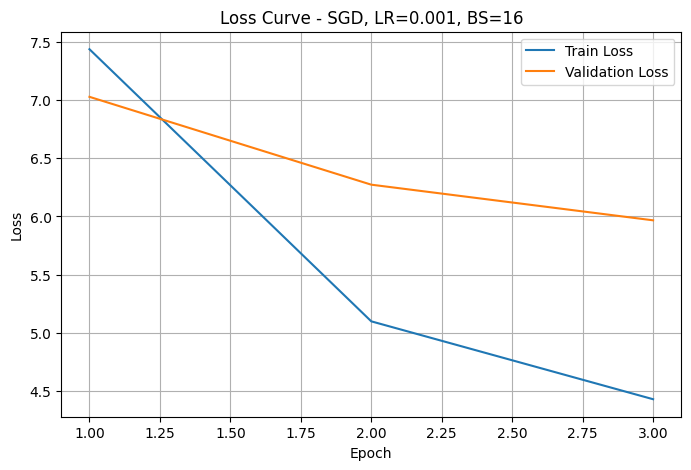

In [43]:
u = YOLO("yolov8x.pt") 
official_model = u.model

results = []

for lr, batch_size, num_epochs, optimizer_name in hyperparameter_combinations:

    print("=" * 50)
    print(f"LR: {lr}")
    print(f"Batch Size: {batch_size}")
    print(f"Epochs: {num_epochs}")
    print(f"Optimizer: {optimizer_name}")

    my_model = YOLOv8("x", nc=3)

    model_dict = my_model.state_dict()
    official_dict = official_model.state_dict()

    new_dict = {}

    for (k1, v1), (k2, v2) in zip(
        model_dict.items(),
        official_dict.items()
    ):
        if v1.shape == v2.shape:
            new_dict[k1] = v2

    my_model.load_state_dict(new_dict, strict=False)
    
    # Freeze Backbone 
    for param in my_model.backbone.parameters():
        param.requires_grad = False

    my_model.to(device)
    criterion = MultiTaskLoss(my_model, lambda_temp=1.0)
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn,
        drop_last=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn
    )

    if optimizer_name == "AdamW":
        optimizer = optim.AdamW(
            filter(lambda p: p.requires_grad, my_model.parameters()),
            lr=lr
        )
    elif optimizer_name == "SGD":
        optimizer = optim.SGD(
            filter(lambda p: p.requires_grad, my_model.parameters()),
            lr=lr,
            momentum=0.9
        )
    elif optimizer_name == "RMSprop":
        optimizer = optim.RMSprop(
            filter(lambda p: p.requires_grad, my_model.parameters()),
            lr=lr
        )

    best_val_loss = float("inf")

    # Tambahan untuk menyimpan loss per epoch
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):

        my_model.train()
        total_train_loss = 0
        total_train_box_loss = 0
        total_train_yolo_cls_loss = 0
        total_train_temp_cls_loss = 0

        for images, targets, temp_labels in train_loader:

            images = images.to(device)
            temp_labels = temp_labels.to(device)
            outputs = my_model(images)
            batch_targets = build_targets(targets, device)
            loss, loss_items = criterion(outputs, batch_targets, temp_labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_train_box_loss += loss_items["box_loss"].item()
            total_train_yolo_cls_loss += loss_items["yolo_cls_loss"].item()
            total_train_temp_cls_loss += loss_items["temp_cls_loss"].item()
            total_train_loss += loss.item()

        avg_train_box_loss = total_train_box_loss / len(train_loader)
        avg_train_yolo_cls_loss = total_train_yolo_cls_loss / len(train_loader)
        avg_train_temp_cls_loss = total_train_temp_cls_loss / len(train_loader)
        avg_train_loss = total_train_loss / len(train_loader)

        my_model.eval()
        total_val_loss = 0
        total_val_box_loss = 0
        total_val_yolo_cls_loss = 0
        total_val_temp_cls_loss = 0

        with torch.no_grad():
            for images, targets, temp_labels in val_loader:

                images = images.to(device)
                temp_labels = temp_labels.to(device)

                outputs = my_model(images)

                batch_targets = build_targets(targets, device)

                loss, loss_items = criterion(outputs, batch_targets, temp_labels)
                
                total_val_loss += loss.item()
                total_val_box_loss += loss_items["box_loss"].item()
                total_val_yolo_cls_loss += loss_items["yolo_cls_loss"].item()
                total_val_temp_cls_loss += loss_items["temp_cls_loss"].item()

        avg_val_loss = total_val_loss / len(val_loader)
        avg_val_box_loss = total_val_box_loss / len(val_loader)
        avg_val_yolo_cls_loss = total_val_yolo_cls_loss / len(val_loader)
        avg_val_temp_cls_loss = total_val_temp_cls_loss / len(val_loader)
        
        # Simpan loss setiap epoch
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {avg_train_loss:.4f} "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Train Box: {avg_train_box_loss:.4f} "
            f"Train YOLO Cls: {avg_train_yolo_cls_loss:.4f} "
            f"Train Temp Cls: {avg_train_temp_cls_loss:.4f} | "
            f"Val Box: {avg_val_box_loss:.4f} "
            f"Val YOLO Cls: {avg_val_yolo_cls_loss:.4f} "
            f"Val Temp Cls: {avg_val_temp_cls_loss:.4f}"
        )

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss

            torch.save(
                my_model.state_dict(),
                f"best_yolov8x_{optimizer_name}_lr{lr}_bs{batch_size}_ep{num_epochs}.pth"
            )

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, num_epochs + 1), train_losses, label="Train Loss")
    plt.plot(range(1, num_epochs + 1), val_losses, label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss Curve - {optimizer_name}, LR={lr}, BS={batch_size}")
    plt.legend()
    plt.grid(True)

    graph_name = f"loss_curve_{optimizer_name}_lr{lr}_bs{batch_size}_ep{num_epochs}.png"
    plt.savefig(graph_name)
    plt.show()

    results.append({
        "lr": lr,
        "batch_size": batch_size,
        "epochs": num_epochs,
        "optimizer": optimizer_name,
        "train_loss": avg_train_loss,
        "val_loss": best_val_loss
    })